# Research Focus Venn Diagram

Build a three-circle linear-layout Venn diagram from the `Paper Type` column of `data/papers.csv`.

Categories:
1. **Experiment on Existing Models**
2. **Benchmark or Dataset**
3. **Experiment on New Models**

Adjacent pairs can overlap (a paper can be in two categories). The non-adjacent pair (existing ↔ new) is not modeled as overlapping in the figure.

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Circle

In [2]:
df = pd.read_csv("../data/papers.csv")
df.shape

(85, 37)

## 1. Inspect raw `Paper Type` values

The CSV mixes a few synonyms (`Benchmark or Dataset` vs `Benchmark / Dataset` vs `Dataset or Benchmark`), has a typo (`Experimental on Existing Models`), and uses a fullwidth comma (`，`) in one row, so we will normalize before counting.

In [3]:
raw_counts = Counter(df["Paper Type"].dropna().astype(str))
for value, count in sorted(raw_counts.items(), key=lambda kv: -kv[1]):
    print(f"{count:>3}  {value!r}")

 63  'Experiment on Existing Models'
  6  'Experiment on Existing Models, Benchmark / Dataset'
  6  'Experiment on Existing Models, Benchmark or Dataset'
  2  'Experimental on Existing Models'
  2  'Benchmark or Dataset, Experiment on Existing Models'
  1  'Dataset or Benchmark, Experiment on Existing Models'
  1  'Experiment on Existing Models, Experiment on New Models'
  1  'Experiment on New Models'
  1  'Benchmark / Dataset, Experiment on Existing Models'
  1  'Experiment on New Models, Experiment on Existing Models'
  1  'Experiment on Existing Models，Experiment on New Models'


## 2. Normalize to three canonical categories

`parse_paper_type` returns a `set` of canonical labels for each row. Anything that does not map cleanly is collected in `unmapped` for inspection.

In [4]:
EXISTING = "Experiment on Existing Models"
BENCHMARK = "Benchmark or Dataset"
NEW = "Experiment on New Models"

ALIASES = {
    "experiment on existing models": EXISTING,
    "experimental on existing models": EXISTING,
    "experiment on new models": NEW,
    "benchmark or dataset": BENCHMARK,
    "benchmark / dataset": BENCHMARK,
    "dataset or benchmark": BENCHMARK,
}

unmapped = Counter()

def parse_paper_type(value):
    if not isinstance(value, str):
        return set()
    cleaned = value.replace("\uFF0C", ",")
    parts = [p.strip() for p in cleaned.split(",") if p.strip()]
    result = set()
    for part in parts:
        key = part.lower()
        if key in ALIASES:
            result.add(ALIASES[key])
        else:
            unmapped[part] += 1
    return result

df["paper_type_set"] = df["Paper Type"].apply(parse_paper_type)
unmapped

Counter()

## 3. Count papers in each Venn region

Seven possible regions on three sets, but the figure shows only the five that are physically present in the linear layout (no triple intersection, no left∩right). Any paper that lands in `Existing ∩ New` or in all three sets is reported separately so it is not silently dropped.

In [5]:
regions = Counter()
for s in df["paper_type_set"]:
    if not s:
        regions["(none)"] += 1
        continue
    key = tuple(sorted(s))
    regions[key] += 1

for k, v in sorted(regions.items(), key=lambda kv: -kv[1]):
    print(f"{v:>3}  {k}")

 65  ('Experiment on Existing Models',)
 16  ('Benchmark or Dataset', 'Experiment on Existing Models')
  3  ('Experiment on Existing Models', 'Experiment on New Models')
  1  ('Experiment on New Models',)


In [6]:
def count_only(*labels):
    target = set(labels)
    return int(sum(s == target for s in df["paper_type_set"]))

n_existing_only = count_only(EXISTING)
n_benchmark_only = count_only(BENCHMARK)
n_new_only = count_only(NEW)
n_existing_and_benchmark = count_only(EXISTING, BENCHMARK)
n_benchmark_and_new = count_only(BENCHMARK, NEW)
n_existing_and_new = count_only(EXISTING, NEW)
n_all_three = count_only(EXISTING, BENCHMARK, NEW)

{
    "existing only": n_existing_only,
    "benchmark only": n_benchmark_only,
    "new only": n_new_only,
    "existing & benchmark": n_existing_and_benchmark,
    "benchmark & new": n_benchmark_and_new,
    "existing & new": n_existing_and_new,
    "all three": n_all_three,
}

{'existing only': 65,
 'benchmark only': 0,
 'new only': 1,
 'existing & benchmark': 16,
 'benchmark & new': 0,
 'existing & new': 3,
 'all three': 0}

## 4. Draw the linear 3-circle Venn diagram

Three equal circles laid out horizontally. Adjacent circles overlap; the outer pair does not. Counts for each visible region are written underneath the labels.

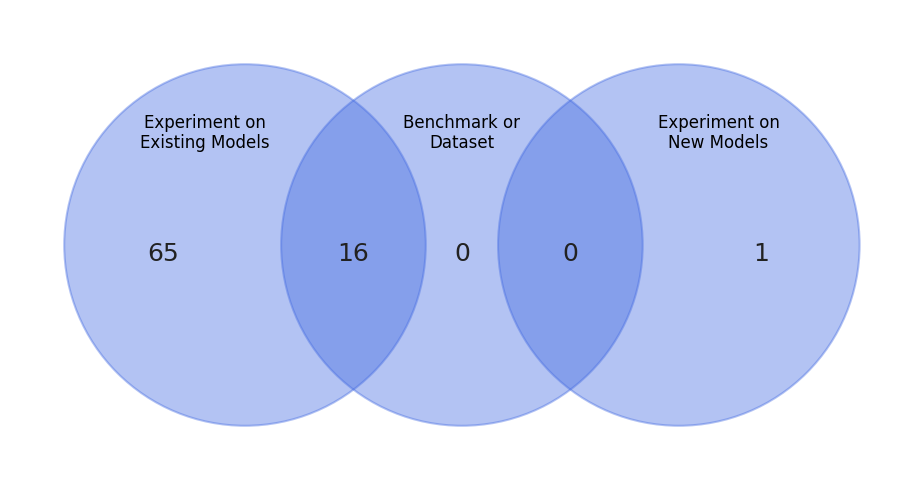

In [7]:
RADIUS = 1.0
CENTER_GAP = 1.2
FACE_COLOR = "royalblue"
EDGE_COLOR = "royalblue"
ALPHA = 0.4

LABEL_FONTSIZE = 12
COUNT_FONTSIZE = 18
LABEL_Y = 0.62
COUNT_Y = -0.05
SIDE_LABEL_INSET = 0.22

centers = {
    EXISTING: (0.0, 0.0),
    BENCHMARK: (CENTER_GAP, 0.0),
    NEW: (2 * CENTER_GAP, 0.0),
}

fig, ax = plt.subplots(figsize=(11, 5))

for label, (cx, cy) in centers.items():
    ax.add_patch(
        Circle(
            (cx, cy),
            RADIUS,
            facecolor=FACE_COLOR,
            edgecolor=EDGE_COLOR,
            linewidth=1.5,
            alpha=ALPHA,
        )
    )

label_positions = {
    EXISTING: (-SIDE_LABEL_INSET, LABEL_Y),
    BENCHMARK: (CENTER_GAP, LABEL_Y),
    NEW: (2 * CENTER_GAP + SIDE_LABEL_INSET, LABEL_Y),
}
count_positions = {
    EXISTING: (-RADIUS / 2.2, COUNT_Y),
    BENCHMARK: (CENTER_GAP, COUNT_Y),
    NEW: (2 * CENTER_GAP + RADIUS / 2.2, COUNT_Y),
}
only_counts = {
    EXISTING: n_existing_only,
    BENCHMARK: n_benchmark_only,
    NEW: n_new_only,
}

wrapped = {
    EXISTING: "Experiment on\nExisting Models",
    BENCHMARK: "Benchmark or\nDataset",
    NEW: "Experiment on\nNew Models",
}

for label, (x, y) in label_positions.items():
    ax.text(x, y, wrapped[label], ha="center", va="center", fontsize=LABEL_FONTSIZE)
for label, (x, y) in count_positions.items():
    ax.text(
        x,
        y,
        f"{only_counts[label]}",
        ha="center",
        va="center",
        fontsize=COUNT_FONTSIZE,
        color="#222222",
    )

intersections = [
    ((centers[EXISTING][0] + centers[BENCHMARK][0]) / 2, n_existing_and_benchmark),
    ((centers[BENCHMARK][0] + centers[NEW][0]) / 2, n_benchmark_and_new),
]
for x, count in intersections:
    ax.text(
        x,
        COUNT_Y,
        f"{count}",
        ha="center",
        va="center",
        fontsize=COUNT_FONTSIZE,
        color="#222222",
    )

ax.set_xlim(-RADIUS - 0.3, 2 * CENTER_GAP + RADIUS + 0.3)
ax.set_ylim(-RADIUS - 0.3, RADIUS + 0.3)
ax.set_aspect("equal")
ax.axis("off")

fig.tight_layout()
fig.savefig("research_focus_venn.png", dpi=200, bbox_inches="tight")
fig.savefig("research_focus_venn.svg", bbox_inches="tight")
plt.show()

## 5. Sanity check

If `existing ∩ new` or the triple intersection is non-zero, the linear figure does not show those papers. Re-check the printout from §3 in that case.

In [8]:
shown = (
    n_existing_only
    + n_benchmark_only
    + n_new_only
    + n_existing_and_benchmark
    + n_benchmark_and_new
)
hidden = n_existing_and_new + n_all_three
missing = int(df["paper_type_set"].apply(len).eq(0).sum())
{
    "papers shown in figure": shown,
    "papers hidden (existing & new, all three)": hidden,
    "papers with no Paper Type": missing,
    "total rows": len(df),
}

{'papers shown in figure': 82,
 'papers hidden (existing & new, all three)': 3,
 'papers with no Paper Type': 0,
 'total rows': 85}